# Import Library :

In [11]:
!pip install  nltk gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.6 MB/s eta 0:00:00


In [12]:
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize

from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns


nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Load Dataset :

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Load CSV
file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Train–Val–Test Split

In [15]:
# ============================================
# PART 2 — Train–Val–Test Split
# ============================================

# Step 1: Pisahkan test 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 2: Dari sisa 80%, ambil 12.5% sebagai validation (~10% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1445
Validation size: 207
Test size: 414


# Load FastText Embedding (dari Google Drive)

In [16]:
from gensim.models import KeyedVectors

# Path file .kv hasil convert
save_path = "/content/drive/MyDrive/DistilBERT-7-Mei/fasttext_id.kv"

# Load cepat
w2v = KeyedVectors.load(save_path, mmap='r')

embedding_dim = w2v.vector_size

print("Embedding dim:", embedding_dim)
print("Jumlah kata:", len(w2v))


Embedding dim: 300
Jumlah kata: 2000000


# Tokenizing + Convert Sentence → Vector

In [17]:
from nltk.tokenize import word_tokenize
import numpy as np

def sentence_to_vector(sentence, w2v, dim):
    tokens = word_tokenize(sentence.lower())
    vecs = []

    for t in tokens:
        if t in w2v.key_to_index:  # Cara yang benar untuk check vocab
            vecs.append(w2v[t])

    if len(vecs) == 0:
        return np.zeros(dim)

    return np.mean(vecs, axis=0)


# Convert Train/Val/Test → Embedding Matrix

In [18]:
import nltk
nltk.download('punkt_tab')

X_train_emb = np.array([sentence_to_vector(sent, w2v, embedding_dim) for sent in X_train])
X_val_emb   = np.array([sentence_to_vector(sent, w2v, embedding_dim) for sent in X_val])
X_test_emb  = np.array([sentence_to_vector(sent, w2v, embedding_dim) for sent in X_test])

print("Vector shapes:")
print(X_train_emb.shape, X_val_emb.shape, X_test_emb.shape)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Vector shapes:
(1445, 300) (207, 300) (414, 300)


In [19]:

from sklearn.svm import SVC
import numpy as np



# Train Final Model dengan Train + Val (FULL TRAINING DATA)

In [20]:
# Best Params: {'C': 1.0, 'kernel': 'linear', 'gamma': -}

final_model = SVC(
    C=1.0,
    kernel= 'linear',
    probability=True,
    random_state=42
)

# Train menggunakan TRAIN + VAL (digabung)
X_fulltrain = np.concatenate([X_train_emb, X_val_emb])
y_fulltrain = pd.concat([y_train, y_val])

final_model.fit(X_fulltrain, y_fulltrain)


SVC(kernel='linear', probability=True, random_state=42)

# FINAL TEST EVALUATION


Classification Report:
              precision    recall  f1-score   support

    Bullying     0.7925    0.9211    0.8519       228
Non-bullying     0.8792    0.7043    0.7821       186

    accuracy                         0.8237       414
   macro avg     0.8358    0.8127    0.8170       414
weighted avg     0.8314    0.8237    0.8206       414



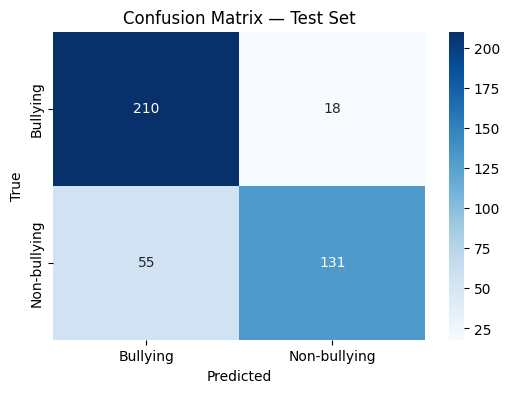

In [21]:
y_pred = final_model.predict(X_test_emb)
test_f1 = f1_score(y_test, y_pred, average="macro")


label_map = {0: "Bullying", 1: "Non-bullying"}
class_names = [label_map[i] for i in sorted(label_map.keys())]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.show()


In [22]:
# === Inference Time Benchmark (selaras dengan BERT) ===
import time
benchmark_size = min(32, len(X_test_emb))
subset = X_test_emb[:benchmark_size]

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")


🕒 Avg batch inference time: 0.0036610984802246094
📊 Throughput: 8740.546088243109 samples/sec
